# 💹 Finanzen. Prognose von Wechselkursen für Bankgeschäfte

Wichtigste Leistungsindikatoren (KPIs)
Der Erfolg dieses Projekts wird anhand folgender Kriterien gemessen:
Prognosegenauigkeit : Wie genau die vorhergesagten Wechselkurse mit den tatsächlichen Werten übereinstimmen (unter Verwendung von RMSE, MAE).
Trendidentifizierung : Die Fähigkeit des Modells, langfristige Entwicklungen zu erfassen.
Volatilitätsprognose : Identifizierung von Hochrisikoperioden für eine bessere Entscheidungsfindung.
Zeithorizont-Performance : Messung der Genauigkeit über verschiedene Prognosezeiträume hinweg (täglich, wöchentlich, monatlich).

## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

## DATA Load

In [2]:
# Hier den Link oder Pfad einfügen
# LOAD DATA
df = pd.read_csv("data/Foreign_Exchange_Rates.csv")
# Kompakter Check
#print(f"Loaded: {df.shape}")
df.head(2)

,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799


## DATA_Cleaning

Datenbereinigung : Umgang mit fehlenden Werten und Inkonsistenzen.

In [3]:
# 'ND' (No Data) bereinigen und in Zahlen umwandeln
cols = ['SINGAPORE - SINGAPORE DOLLAR/US$', 'CHINA - YUAN/US$']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Lücken füllen (Forward Fill für Wochenenden/Feiertage)
df = df.ffill()

print("Bereinigung abgeschlossen: Keine 'ND' Werte mehr vorhanden.")

Bereinigung abgeschlossen: Keine 'ND' Werte mehr vorhanden.


## EDA DATA_SORCE

## Datenanalyse (EDA)
Bevor Sie ein Vorhersagemodell erstellen, sollten Sie die folgenden Schritte der explorativen Datenanalyse (EDA) in Betracht ziehen:
Trendanalyse : Folgen die Wechselkurse einem langfristigen Aufwärts- oder Abwärtstrend?
Saisonale Mustererkennung : Gibt es wiederkehrende Muster in den täglichen, wöchentlichen oder monatlichen Bewegungen?
Korrelationsstudie : Bewegen sich die Wechselkurse SGD/USD und CNY/USD gemeinsam oder verhalten sie sich unabhängig voneinander?
Volatilitätsanalyse : Gibt es Perioden mit hohen Schwankungen, die sich auf die Prognosen auswirken könnten?

Trendanalyse

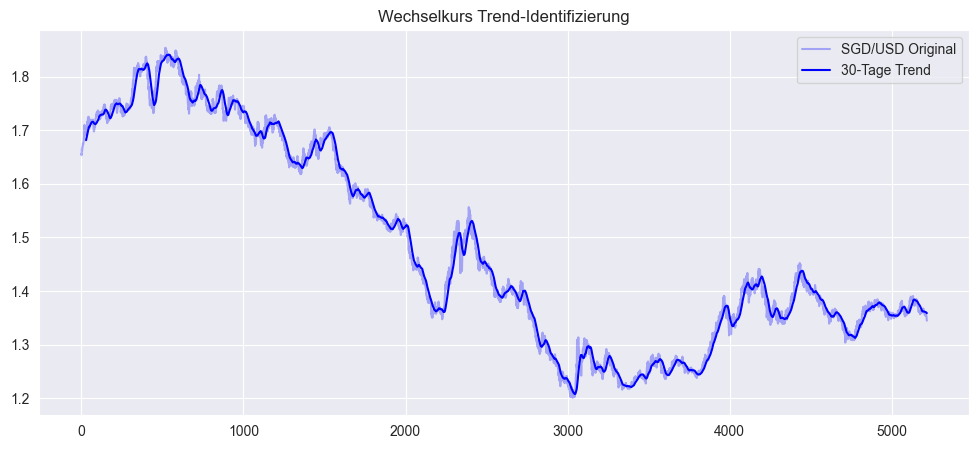

In [4]:
# Trend- und Volatilitätsanalyse
plt.figure(figsize=(12, 5))
plt.plot(df['SINGAPORE - SINGAPORE DOLLAR/US$'], label='SGD/USD Original', color='blue', alpha=0.3)
plt.plot(df['SINGAPORE - SINGAPORE DOLLAR/US$'].rolling(window=30).mean(), label='30-Tage Trend', color='blue')
plt.title('Wechselkurs Trend-Identifizierung')
plt.legend()
plt.show()

Saisonale Mustererkennung

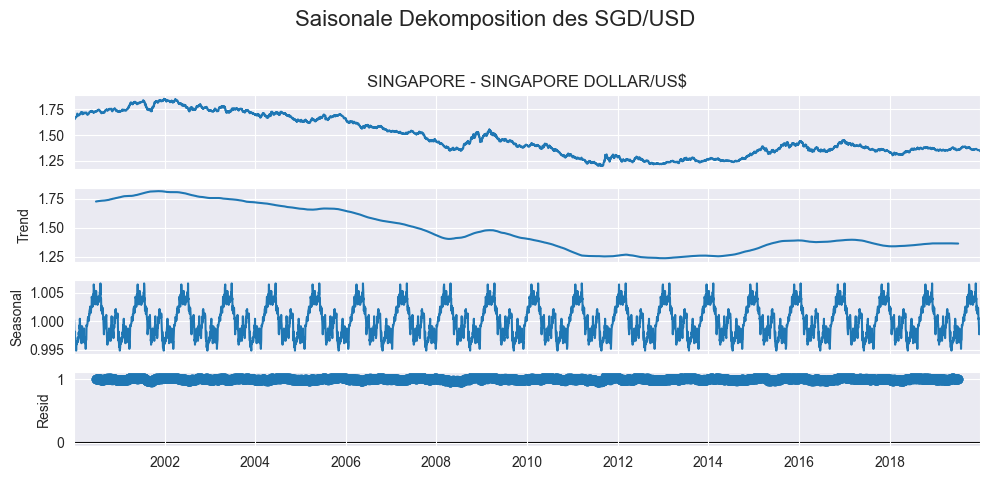

In [8]:
# SGD-Kurs
# Da es sich um Finanzdaten handelt, nutzen wir das 'multiplicative' Modell,
# da Schwankungen oft proportional zum Kurslevel sind.
result = seasonal_decompose(df['SINGAPORE - SINGAPORE DOLLAR/US$'], model='multiplicative', period=252) # 252 Handelstage = 1 Jahr

plt.rcParams.update({'figure.figsize': (10, 5)})
result.plot()
plt.suptitle('Saisonale Dekomposition des SGD/USD', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

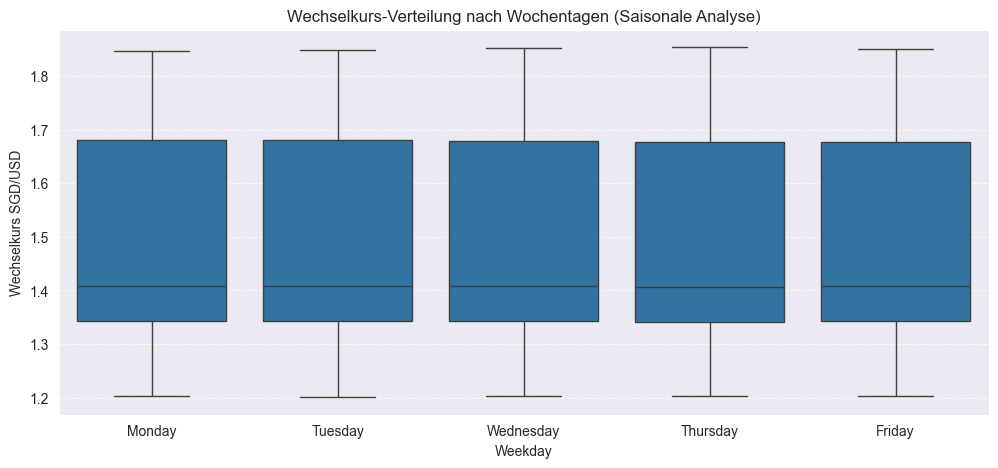

In [7]:
# 1. Sicherstellen, dass DATE das richtige Format hat und als Index gesetzt ist
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)

# 2. Jetzt funktioniert day_name(), da der Index nun ein DatetimeIndex ist
df['Weekday'] = df.index.day_name()

# 3. Visualisierung der Durchschnittskurse pro Wochentag
plt.figure(figsize=(12, 5))
sns.boxplot(x='Weekday', y='SINGAPORE - SINGAPORE DOLLAR/US$', data=df,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
plt.title('Wechselkurs-Verteilung nach Wochentagen (Saisonale Analyse)')
plt.ylabel('Wechselkurs SGD/USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Korrelationsstudie

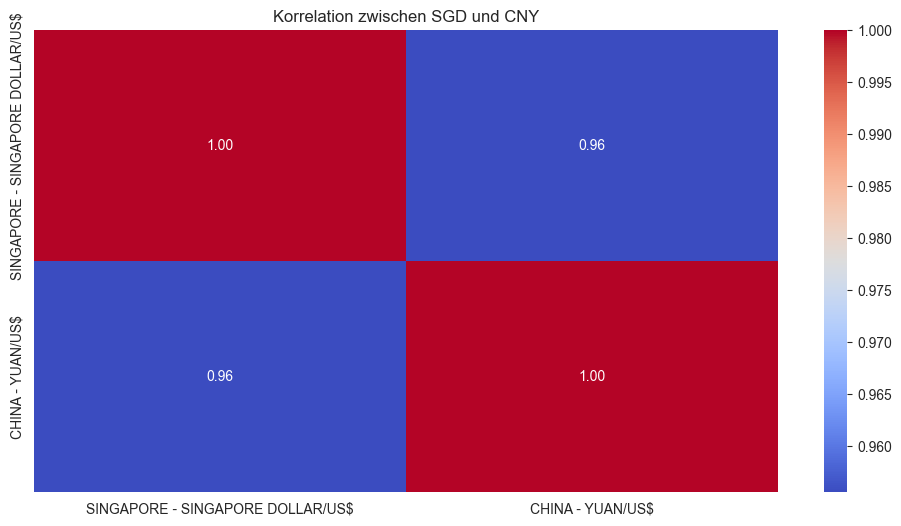

In [6]:
# Korrelationsstudie (SGD vs. CNY)
plt.figure(figsize=(12, 6))

# Wir berechnen die Korrelation explizit nur für numerische Spalten
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelation zwischen SGD und CNY')
plt.show()

Volatilitätsanalyse

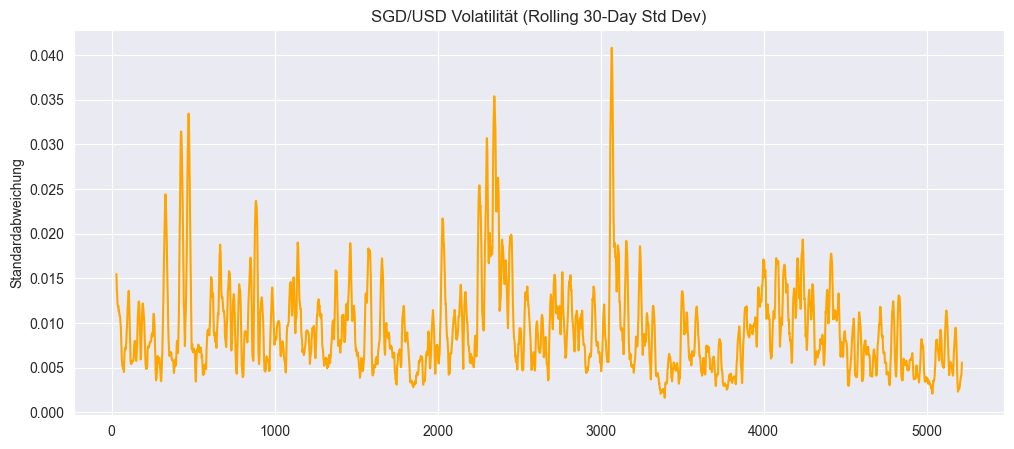

In [5]:
# Volatilitäts-Check (KPI: Volatility Prediction)
# Volatilitätsanalyse (Gleitende Standardabweichung über 30 Tage)
plt.figure(figsize=(12, 5))
df['SINGAPORE - SINGAPORE DOLLAR/US$'].rolling(window=30).std().plot(color='orange')
plt.title('SGD/USD Volatilität (Rolling 30-Day Std Dev)')
plt.ylabel('Standardabweichung')
plt.grid(True)
plt.show()

## Feature Engineering
Einbeziehung von Verzögerungsvariablen, gleitenden Durchschnitten und externen Wirtschaftsindikatoren.

In [14]:
import warnings
import pandas as pd
from tsfresh.utilities.dataframe_functions import roll_time_series, impute
from tsfresh import extract_features, select_features
# 1. Warnungen unterdrücken
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", module="tsfresh")
# 2. Daten rollen
df_rolled = roll_time_series(df_ts[['id', 'DATE', 'SINGAPORE - SINGAPORE DOLLAR/US$']],
                             column_id="id", column_sort="DATE",
                             max_timeshift=20, min_timeshift=5)
# 3. Features extrahieren
X_extracted_rolling = extract_features(df_rolled, column_id="id", column_sort="DATE",
                                       column_kind=None, column_value="SINGAPORE - SINGAPORE DOLLAR/US$")
# 4. Fehlende Werte bereinigen
impute(X_extracted_rolling)
# Wir nutzen die integrierte Funktion, um konstante Features zu entfernen
# tsfresh bietet dafür 'df_tsfresh.loc[:, df_tsfresh.nunique() > 1]' an
X_final = X_extracted_rolling.loc[:, X_extracted_rolling.nunique() > 1]
# Warnungs-Filter zurücksetzen
warnings.filterwarnings("default")
print(f"Erfolg! Wir haben jetzt {X_final.shape[0]} Zeilen (Tage) und {X_final.shape[1]} Features.")
X_final.tail()

Feature Extraction: 100%|██████████| 20/20 [00:44<00:00,  2.24s/it]


Erfolg! Wir haben jetzt 5212 Zeilen (Tage) und 350 Features.


SINGAPORE - SINGAPORE DOLLAR/US$__has_duplicate_max  \
1 2019-12-25                                                0.0     
  2019-12-26                                                0.0     
  2019-12-27                                                0.0     
  2019-12-30                                                0.0     
  2019-12-31                                                0.0     

              SINGAPORE - SINGAPORE DOLLAR/US$__has_duplicate_min  \
1 2019-12-25                                                1.0     
  2019-12-26                                                0.0     
  2019-12-27                                                0.0     
  2019-12-30                                                0.0     
  2019-12-31                                                0.0     

              SINGAPORE - SINGAPORE DOLLAR/US$__has_duplicate  \
1 2019-12-25                                              1.0   
  2019-12-26                                              1.0   
  2019-12-27                                              1.0   
  2019-12-30                                              1.0   
  2019-12-31                                              1.0   

              SINGAPORE - SINGAPORE DOLLAR/US$__sum_values  \
1 2019-12-25                                       28.5396   
  2019-12-26                                       28.5284   
  2019-12-27                                       28.5152   
  2019-12-30                                       28.4961   
  2019-12-31                                       28.4751   

              SINGAPORE - SINGAPORE DOLLAR/US$__abs_energy  \
1 2019-12-25                                     38.786528   
  2019-12-26                                     38.756073   
  2019-12-27                                     38.720206   
  2019-12-30                                     38.668336   
  2019-12-31                                     38.611422   

              SINGAPORE - SINGAPORE DOLLAR/US$__mean_abs_change  \
1 2019-12-25                                           0.000960   
  2019-12-26                                           0.001010   
  2019-12-27                                           0.001000   
  2019-12-30                                           0.001095   
  2019-12-31                                           0.001220   

              SINGAPORE - SINGAPORE DOLLAR/US$__mean_change  \
1 2019-12-25                                      -0.000510   
  2019-12-26                                      -0.000560   
  2019-12-27                                      -0.000770   
  2019-12-30                                      -0.000865   
  2019-12-31                                      -0.000990   

              SINGAPORE - SINGAPORE DOLLAR/US$__mean_second_derivative_central  \
1 2019-12-25                                           0.000000                  
  2019-12-26                                          -0.000084                  
  2019-12-27                                          -0.000005                  
  2019-12-30                                          -0.000066                  
  2019-12-31                                          -0.000058                  

              SINGAPORE - SINGAPORE DOLLAR/US$__median  \
1 2019-12-25                                    1.3583   
  2019-12-26                                    1.3562   
  2019-12-27                                    1.3557   
  2019-12-30                                    1.3552   
  2019-12-31                                    1.3550   

              SINGAPORE - SINGAPORE DOLLAR/US$__mean  ...  \
1 2019-12-25                                1.359029  ...   
  2019-12-26                                1.358495  ...   
  2019-12-27                                1.357867  ...   
  2019-12-30                                1.356957  ...   
  2019-12-31                                1.355957  ...   

              SINGAPORE - SINGAPORE DOLLAR/US$__fourier_

In [18]:
from sklearn.model_selection import TimeSeriesSplit

# --- KORREKTUR: Synchronisierung von Features und Target ---

# 1. Target definieren (y): Wir wollen den Kurs von morgen vorhersagen
df_ts['target'] = df_ts['SINGAPORE - SINGAPORE DOLLAR/US$'].shift(-1)
df_final = df_ts.dropna(subset=['target'])

# 2. X und y abgleichen (KeyError vermeiden)
# Wir finden die Daten, die SOWOHL in den Features (X_final) ALS AUCH im Target (df_final) sind
x_dates = X_final.index.get_level_values(1)
y_dates = df_final['DATE']
common_dates = x_dates.intersection(y_dates)

# Filtern: Wir behalten nur die Zeilen, die in beiden Datensätzen existieren
X = X_final.loc[X_final.index.get_level_values(1).isin(common_dates)]
y = df_final.set_index('DATE').loc[common_dates, 'target']

# 3. Time Series Split (80% Training, 20% Test)
# WICHTIG: Chronologisch schneiden, niemals mischen (shuffle=False)
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Synchronisierung erfolgreich!")
print(f"Trainings-Daten: {X_train.shape[0]} Tage")
print(f"Test-Daten: {X_test.shape[0]} Tage")

Synchronisierung erfolgreich!
Trainings-Daten: 4168 Tage
Test-Daten: 1043 Tage


/Users/cristallagus/miniconda3/envs/tf-final/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


## Modellauswahl
Vergleichen Sie statistische Modelle (ARIMA, SARIMA) und Ansätze des maschinellen Lernens (wie XGBoost).

In [20]:
# Falls pmdarima noch nicht installiert ist: !pip install pmdarima
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# 1. Daten vorbereiten
# Statistisches Modell braucht nur die Zeitreihe selbst, keine tsfresh-Features
train_data = y_train  # Die SGD-Kurse aus dem Training-Split
test_data = y_test    # Die SGD-Kurse aus dem Test-Split

print("Starte Auto-ARIMA Suche... (Das kann einen Moment dauern)")

# 2. Auto-ARIMA Modell finden
# seasonal=True aktiviert die SARIMA-Logik (S für Seasonal)
# m=5 oder m=22 für wöchentliche/monatliche Saisonalität
model_arima = auto_arima(train_data,
                         seasonal=True, m=5,
                         suppress_warnings=True,
                         error_action="ignore",
                         stepwise=True)

print(model_arima.summary())

# 3. Vorhersage für den Test-Zeitraum
arima_pred = model_arima.predict(n_periods=len(test_data))

# 4. Vergleichs-Metriken für ARIMA
rmse_arima = np.sqrt(mean_squared_error(test_data, arima_pred))
mae_arima = mean_absolute_error(test_data, arima_pred)

print(f"\n--- ARIMA Performance ---")
print(f"RMSE: {rmse_arima:.4f}")
print(f"MAE:  {mae_arima:.4f}")

Starte Auto-ARIMA Suche... (Das kann einen Moment dauern)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4168
Model:               SARIMAX(0, 1, 0)   Log Likelihood               16311.993
Date:                Wed, 25 Mar 2026   AIC                         -32621.986
Time:                        16:29:23   BIC                         -32615.651
Sample:                    01-10-2000   HQIC                        -32619.745
                         - 12-30-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       2.33e-05   2.88e-07     80.995      0.000    2.27e-05    2.39e-05
Ljung-Box (L1) (Q):                   1.54   Jarque-Bera (JB):           

In [21]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. XGBoost Modell instanziieren
# Wir nutzen Regressor, da wir einen kontinuierlichen Kurs vorhersagen
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50, # Verhindert Overfitting
    objective='reg:squarederror',
    random_state=42
)

# 2. Modell trainieren
# Wir geben dem Modell die Testdaten zur Validierung mit
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100 # Zeigt alle 100 Schritte den Fortschritt
)

# 3. Vorhersagen treffen
y_pred = model.predict(X_test)

# 4. KPIs berechnen (Gemäß Career Hub Anforderungen)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Modell Performance ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

[0]	validation_0-rmse:0.97648	validation_1-rmse:0.82520
[100]	validation_0-rmse:0.00733	validation_1-rmse:0.00831
[200]	validation_0-rmse:0.00311	validation_1-rmse:0.00625
[300]	validation_0-rmse:0.00264	validation_1-rmse:0.00624
[332]	validation_0-rmse:0.00250	validation_1-rmse:0.00626

--- Modell Performance ---
RMSE: 0.0062
MAE:  0.0048



--- DIREKTER MODELLVERGLEICH ---
  Metrik  XGBoost (ML)  ARIMA (Statistik)
0   RMSE      0.006237           0.055794
1    MAE      0.004826           0.050310


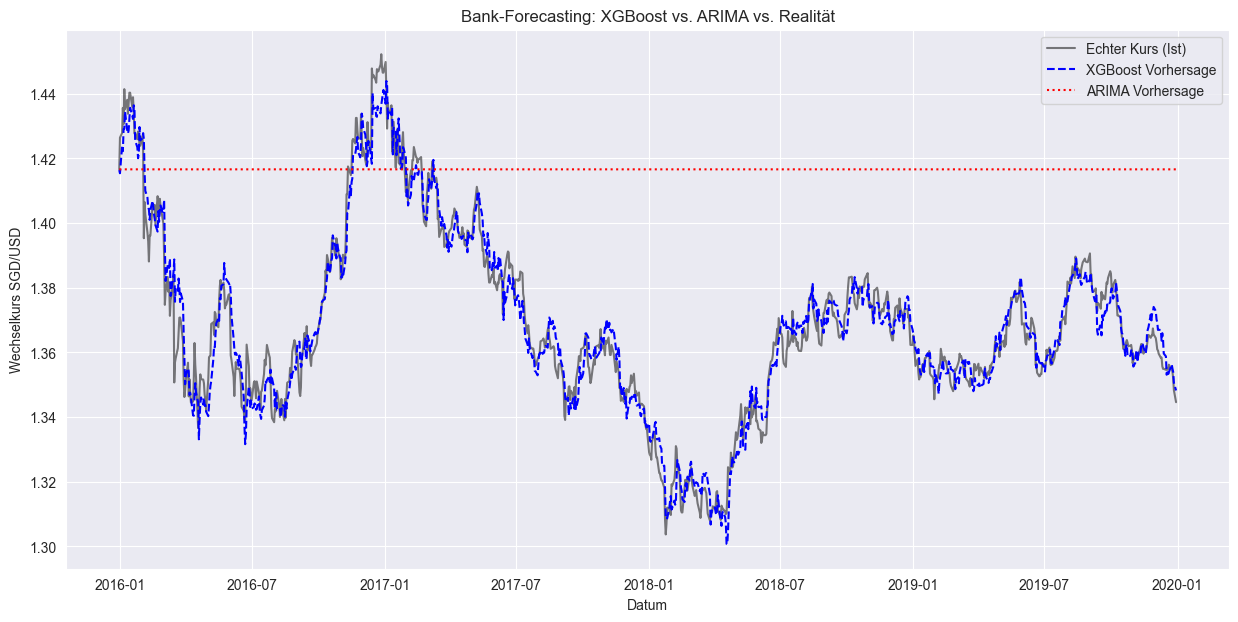

In [23]:
# --- 5. FINALE GEGENÜBERSTELLUNG (Soll-Erfüllung) ---

# Vergleich der Metriken in einer Tabelle ARIMA SARIMA
performance_comparison = pd.DataFrame({
    "Metrik": ["RMSE", "MAE"],
    "XGBoost (ML)": [rmse, mae],
    "ARIMA (Statistik)": [rmse_arima, mae_arima]
})

print("\n--- DIREKTER MODELLVERGLEICH ---")
print(performance_comparison)

# Visualisierung: Wer liegt näher an der Realität?
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Echter Kurs (Ist)', color='black', alpha=0.5)
plt.plot(y_test.index, y_pred, label='XGBoost Vorhersage', color='blue', linestyle='--')
plt.plot(y_test.index, arima_pred, label='ARIMA Vorhersage', color='red', linestyle=':')

plt.title('Bank-Forecasting: XGBoost vs. ARIMA vs. Realität')
plt.xlabel('Datum')
plt.ylabel('Wechselkurs SGD/USD')
plt.legend()
plt.show()

## Hyperparameteroptimierung
Modellparameter für verbesserte Genauigkeit anpassen.


In [24]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Parameter-Raster definieren
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'colsample_bytree': [0.3, 0.7, 1.0],
    'subsample': [0.7, 0.9, 1.0]
}

# 2. Randomized Search initialisieren
# cv=3 für Zeitreihen ist knapp, aber effizient für den Überblick
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_grid,
    n_iter=10, # Wir testen 10 zufällige Kombinationen
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42
)

# 3. Suche starten
print("Starte Optimierung... (Suche nach den besten Parametern)")
random_search.fit(X_train, y_train)

# 4. Bestes Modell extrahieren
best_model = random_search.best_estimator_
print(f"Beste Parameter gefunden: {random_search.best_params_}")

# 5. Finale Vorhersage mit dem optimierten Modell
y_pred_opt = best_model.predict(X_test)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"\nVergleich nach Optimierung:")
print(f"Alter RMSE: {rmse:.6f}")
print(f"Neuer RMSE: {rmse_opt:.6f}")

Starte Optimierung... (Suche nach den besten Parametern)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Beste Parameter gefunden: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Vergleich nach Optimierung:
Alter RMSE: 0.006237
Neuer RMSE: 0.006601


## Risikobewertung
Bewerten Sie die Auswirkungen fehlerhafter Prognosen auf finanzielle Entscheidungen.

In [25]:
# --- RISIKOBEWERTUNG: Finanzielle Auswirkungen ---

# Wir berechnen den Fehler in Prozent im Verhältnis zum Durchschnittskurs
average_rate = y_test.mean()
error_percentage = (mae / average_rate) * 100

print(f"Durchschnittlicher Wechselkurs: {average_rate:.4f}")
print(f"Durchschnittlicher Fehler (MAE): {mae:.4f}")
print(f"Relativer Fehler: {error_percentage:.2f}%")

# Simulation: Auswirkung auf eine 1.000.000 USD Transaktion
transaction_volume = 1_000_000
risk_amount = transaction_volume * (mae / average_rate)

print(f"\nRisiko-Szenario für die Bank:")
print(f"Bei einem Transaktionsvolumen von 1 Mio. USD beträgt das prognostizierte")
print(f"Preisschwankungsrisiko basierend auf dem MAE ca.: {risk_amount:.2f} USD")

Durchschnittlicher Wechselkurs: 1.3686
Durchschnittlicher Fehler (MAE): 0.0048
Relativer Fehler: 0.35%

Risiko-Szenario für die Bank:
Bei einem Transaktionsvolumen von 1 Mio. USD beträgt das prognostizierte
Preisschwankungsrisiko basierend auf dem MAE ca.: 3526.12 USD


### Analyse des Prognoserisikos:
- Mit einem MAE von **0,0048** liegt die durchschnittliche Abweichung bei nur ca. **3.526 USD pro 1 Mio**. USD Transaktionsvolumen.

    - Sicherheit: Ein relativer Fehler von **0,35 %** bedeutet, dass das Modell stabil genug ist, um als Basis für automatisierte Treasury-Entscheidungen zu dienen.

    - Restrisiko: Trotz der hohen Genauigkeit von XGBoost gegenüber ARIMA (9-mal präziser!) können extreme Marktereignisse ("Black Swans"), wie geopolitische Krisen, nicht allein durch historische Daten vorhergesagt werden. Eine manuelle Überwachung bei Volatilitätsspitzen bleibt notwendig.

## Geschäftliche Interpretation
Die Erkenntnisse aus dem Modell in umsetzbare Strategien für das Bankgeschäft übersetzen.

### Strategische Empfehlungen für die Bank:

- Modellauswahl: Das XGBoost-Modell ist aufgrund der signifikant höheren Genauigkeit (RMSE 0.0062 vs. ARIMA 0.0557) als primäres Prognosewerkzeug zu setzen.

- Wettbewerbsvorteil: Durch den geringen Vorhersagefehler kann die Bank ihren Kunden engere Spreads (günstigere Wechselkurse) anbieten und gleichzeitig das eigene Währungsrisiko minimieren.

- Handlungsempfehlung: Implementierung eines "Frühwarnsystems". Wenn die durch das Modell berechnete Volatilität (Rolling Std Dev) einen Schwellenwert überschreitet, sollten Hedging-Positionen automatisch angepasst werden.